#### Load Datasets

In [103]:
%store -r X_train_scaled
%store -r X_test_scaled
%store -r X_scaled
%store -r y_train
%store -r y_test
%store -r y_dataset

#### Libraries

In [104]:
import pandas as pd
import numpy as np

from sklearn import svm
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate, KFold

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, roc_auc_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

from sklearn.exceptions import UndefinedMetricWarning
import warnings

# Suppress UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

### Support Vector Machine Model

##### Best C, Kernek & gamma

In [105]:
# Πιθανοί Kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Τιμές για το C
C_space = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Τιμές για το γ
gamma_space = [0.001, 0.01, 0.1, 1, 10]

# Create the parameter grid
param_grid = {'C': C_space, 'kernel': kernels, 'gamma': gamma_space}

# Create the SVM model
svm = SVC()

# Δημιουργία του gridsearch για εύρεση C και Kernel βάσει μέσης ακρίβειας σε κάθε fold
grid_search = GridSearchCV(svm, param_grid=param_grid, cv=5, scoring='accuracy', refit=True, verbose=1)

# Fit the model to the training data
grid_search.fit(X_train_scaled, y_train)

best_kernel = grid_search.best_params_['kernel']
best_C = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']

print("Best Kernel:", best_kernel)
print("Best C:", best_C)
print("Best gamma:", best_gamma)

# Εύρεση του μέγιστου score που πετυχαίνεται
best_score = grid_search.best_score_
print("Best Score:", best_score)

# Μέσες τιμές για κάθε C value
mean_test_scores = grid_search.cv_results_['mean_test_score']
params = grid_search.cv_results_['params']

# Εκτύπωση των μέσων τιμών ακρίβειας για κάθε τιμή του C
for param, score in zip(params, mean_test_scores):
    print(f"C: {param['C']}, Kernel: {param['kernel']}, Gamma: {param['gamma']}, Mean Test Score: {score * 100:.2f}%")


Fitting 5 folds for each of 140 candidates, totalling 700 fits
Best Kernel: poly
Best C: 0.1
Best gamma: 10
Best Score: 0.9949999999999999
C: 0.001, Kernel: linear, Gamma: 0.001, Mean Test Score: 33.00%
C: 0.001, Kernel: poly, Gamma: 0.001, Mean Test Score: 33.00%
C: 0.001, Kernel: rbf, Gamma: 0.001, Mean Test Score: 33.00%
C: 0.001, Kernel: sigmoid, Gamma: 0.001, Mean Test Score: 33.00%
C: 0.001, Kernel: linear, Gamma: 0.01, Mean Test Score: 33.00%
C: 0.001, Kernel: poly, Gamma: 0.01, Mean Test Score: 33.00%
C: 0.001, Kernel: rbf, Gamma: 0.01, Mean Test Score: 33.00%
C: 0.001, Kernel: sigmoid, Gamma: 0.01, Mean Test Score: 33.00%
C: 0.001, Kernel: linear, Gamma: 0.1, Mean Test Score: 33.00%
C: 0.001, Kernel: poly, Gamma: 0.1, Mean Test Score: 33.00%
C: 0.001, Kernel: rbf, Gamma: 0.1, Mean Test Score: 33.00%
C: 0.001, Kernel: sigmoid, Gamma: 0.1, Mean Test Score: 33.00%
C: 0.001, Kernel: linear, Gamma: 1, Mean Test Score: 33.00%
C: 0.001, Kernel: poly, Gamma: 1, Mean Test Score: 33.17%

##### Υλοποίηση Μοντέλου SVM

In [106]:
svm_model = SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, probability=True)
svm_model.fit(X_train_scaled, y_train)

SVC(C=0.1, gamma=10, kernel='poly', probability=True)

#### Evaluation on Training Data

In [107]:
y_train_pred = svm_model.predict(X_train_scaled)
y_train_pred_proba = svm_model.predict_proba(X_train_scaled)

# Precision
svm_precision_train = precision_score(y_train, y_train_pred, average='weighted')

# Recall
svm_recall_train = recall_score(y_train, y_train_pred, average='weighted')

# F1-Score
svm_f1_train = f1_score(y_train, y_train_pred, average='weighted')

# Classification Accuracy
svm_accuracy_train = accuracy_score(y_train, y_train_pred)

# Confusion Matrix
svm_conf_matrix_train = confusion_matrix(y_train, y_train_pred)

# Log Loss
svm_log_loss_value_train = log_loss(y_train, y_train_pred_proba)

# AROC Curve
svm_roc_auc_train = roc_auc_score(y_train, y_train_pred_proba, multi_class='ovr', labels=svm_model.classes_)

# Evaluation Metrics
print(f'\nTraining Confusion Matrix:\n{svm_conf_matrix_train}')
print(f'Training Area Under the ROC Curve (AROC): {svm_roc_auc_train}')
print(f'Training Accuracy: {svm_accuracy_train}')
print(f'Training F1-Score: {svm_f1_train}')
print(f'Training Precision: {svm_precision_train}')
print(f'Training Recall: {svm_recall_train}')
print(f'Training Log Loss: {svm_log_loss_value_train}')


Training Confusion Matrix:
[[100   0   0   0]
 [  0 153   0   0]
 [  0   0 149   0]
 [  0   0   0 198]]
Training Area Under the ROC Curve (AROC): 1.0
Training Accuracy: 1.0
Training F1-Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training Log Loss: 0.073960832288592


#### Evaluation on Test Data

In [108]:
y_test_pred = svm_model.predict(X_test_scaled)
y_test_pred_proba = svm_model.predict_proba(X_test_scaled)

# Precision
svm_precision_test = precision_score(y_test, y_test_pred, average='weighted')
%store svm_precision_test

# Recall
svm_recall_test = recall_score(y_test, y_test_pred, average='weighted')
%store svm_recall_test

# F1-Score
svm_f1_test = f1_score(y_test, y_test_pred, average='weighted')
%store svm_f1_test

# Classification Accuracy
svm_accuracy_test = accuracy_score(y_test, y_test_pred)
%store svm_accuracy_test

# Log Loss
svm_log_loss_value_test = log_loss(y_test, y_test_pred_proba, labels=svm_model.classes_)
%store svm_log_loss_value_test

# Confusion Matrix
svm_conf_matrix_test = confusion_matrix(y_test, y_test_pred)
%store svm_conf_matrix_test

# AROC Curve
svm_roc_auc_test = roc_auc_score(y_test, y_test_pred_proba, multi_class='ovr', labels=svm_model.classes_)
%store svm_roc_auc_test

# Evaluation Metrics
print(f'\nTest Confusion Matrix:\n{svm_conf_matrix_test}')
print(f'\nTest Area Under the ROC Curve (AROC): {svm_roc_auc_test}')
print(f'Test Accuracy: {svm_accuracy_test}')
print(f'Test F1-Score: {svm_f1_test}')
print(f'Test Precision: {svm_precision_test}')
print(f'Test Recall: {svm_recall_test}')
print(f'Test Log Loss: {svm_log_loss_value_test}')

Stored 'svm_precision_test' (float64)
Stored 'svm_recall_test' (float64)
Stored 'svm_f1_test' (float64)
Stored 'svm_accuracy_test' (float64)
Stored 'svm_log_loss_value_test' (float64)
Stored 'svm_conf_matrix_test' (ndarray)
Stored 'svm_roc_auc_test' (float64)

Test Confusion Matrix:
[[19  0  6  0]
 [ 8 13  4  0]
 [ 5 13  7  0]
 [ 0  0  0 25]]

Test Area Under the ROC Curve (AROC): 0.8574666666666666
Test Accuracy: 0.64
Test F1-Score: 0.6274509803921567
Test Precision: 0.6263786764705883
Test Recall: 0.64
Test Log Loss: 2.073359221552708


### Plot Results
#### Confusion Matrix

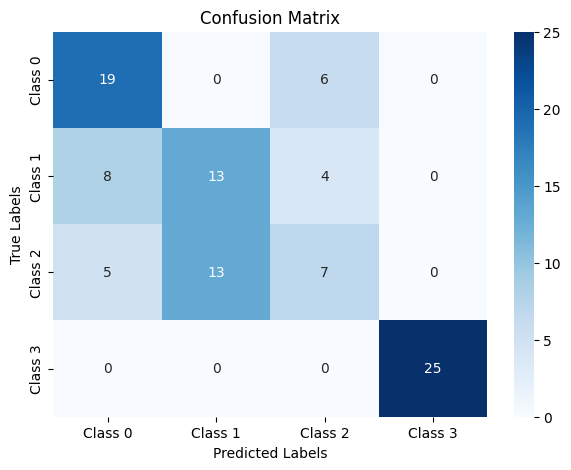

In [109]:
# Plot confusion matrix 
plt.figure(figsize=(7, 5))
sns.heatmap(svm_conf_matrix_test, annot=True, fmt='g', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Receiver Operating Characteristic (ROC) Curve

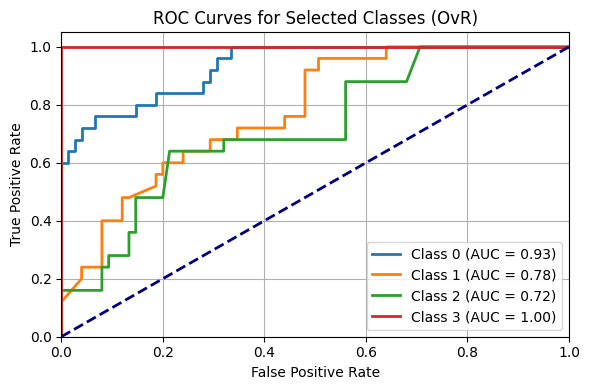

In [110]:
selected_classes = [0, 1, 2, 3]
plt.figure(figsize=(6, 4))

for class_label in selected_classes:
    y_test_binary = (y_test == class_label).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_proba[:, class_label])
    roc_auc = auc(fpr, tpr)
    
    # Customize κάθε κλάση
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})', 
             color=plt.cm.get_cmap('tab10')(class_label), linestyle='-', linewidth=2)

# Plot the diagonal line 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Selected Classes (OvR)')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()

#### Precision, Recall, F1 Score, Accuracy

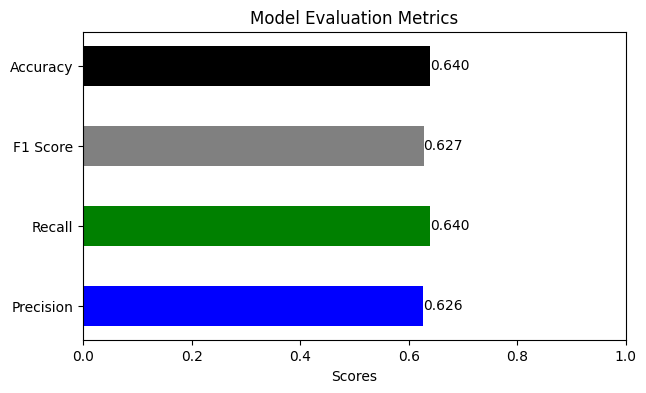

In [111]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [svm_precision_test, svm_recall_test, svm_f1_test, svm_accuracy_test]
bar_width = 0.5

# Plot horizontal bars
bars = ax.barh(metrics, scores, height=bar_width, color=['blue', 'green', 'grey', 'black'])

# Display actual values 
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

ax.set_xlim(0, 1)
plt.show()

#### Support Vector Machines Algorithm with 5fold Cross Validation

In [112]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
svm_5cross = SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, probability=True)

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']

cv_results = cross_validate(svm_5cross, X_scaled, y_dataset, cv=kf, scoring=scoring_metrics, return_train_score=False)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]}")
    print(f"Precision: {cv_results['test_precision_weighted'][fold-1]}")
    print(f"Recall: {cv_results['test_recall_weighted'][fold-1]}")
    print(f"F1 Score: {cv_results['test_f1_weighted'][fold-1]}")
    print(f"Log Loss: {abs(np.mean(cv_results['test_neg_log_loss'][fold-1]))}")
    print(f"ROC AUC: {cv_results['test_roc_auc_ovo_weighted'][fold-1]}")
    print("--"*100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'neg_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")

Fold 1 Metrics:
Accuracy: 0.9928571428571429
Precision: 0.9930158730158729
Recall: 0.9928571428571429
F1 Score: 0.9928346146264536
Log Loss: 0.11147024620793515
ROC AUC: 0.9999318928198239
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.9714285714285714
Precision: 0.9742160278745644
Recall: 0.9714285714285714
F1 Score: 0.971464308049674
Log Loss: 0.16124634711398333
ROC AUC: 0.9978275929584068
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.9857142857142858
Precision: 0.9861990950226245
Recall: 0.9857142857142858
F1 Score: 0.9856144043438272
Log Loss: 0.1643295203525583
ROC AUC: 0.9987734487734486
---------------------------------

##### Plot the Cross Valdation Results

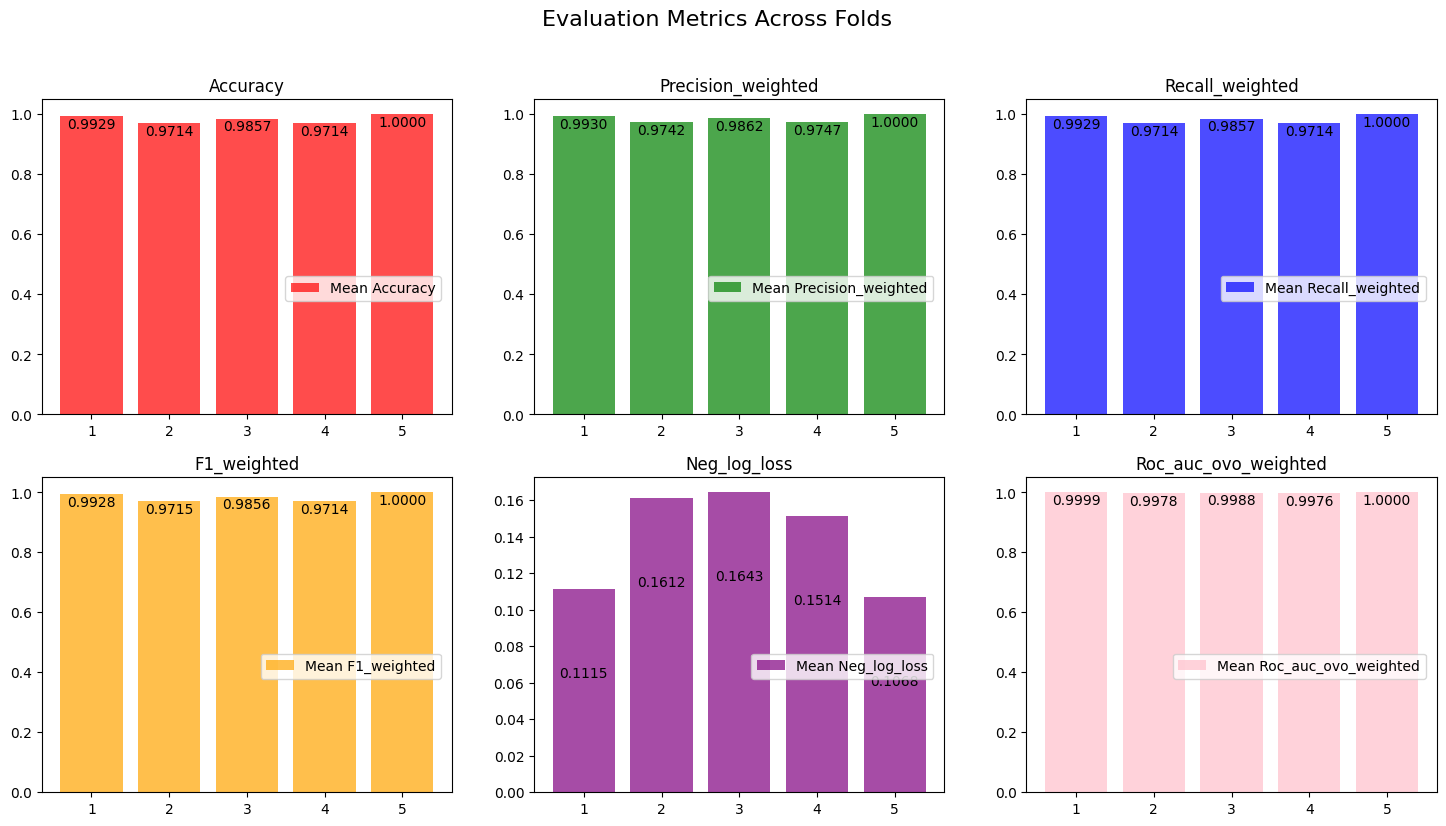

In [113]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function για τς τιμές μέσα στις μπάρες
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink']  

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 3
    col = idx % 3

    if metric == 'neg_log_loss':
        metric_values = np.abs(cv_results[f'test_{metric}'])
    else:
        metric_values = cv_results[f'test_{metric}']

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

if len(metrics_to_plot) < 6:
    fig.delaxes(axes[-1, -1])

plt.subplots_adjust(hspace=0.2)
plt.show()